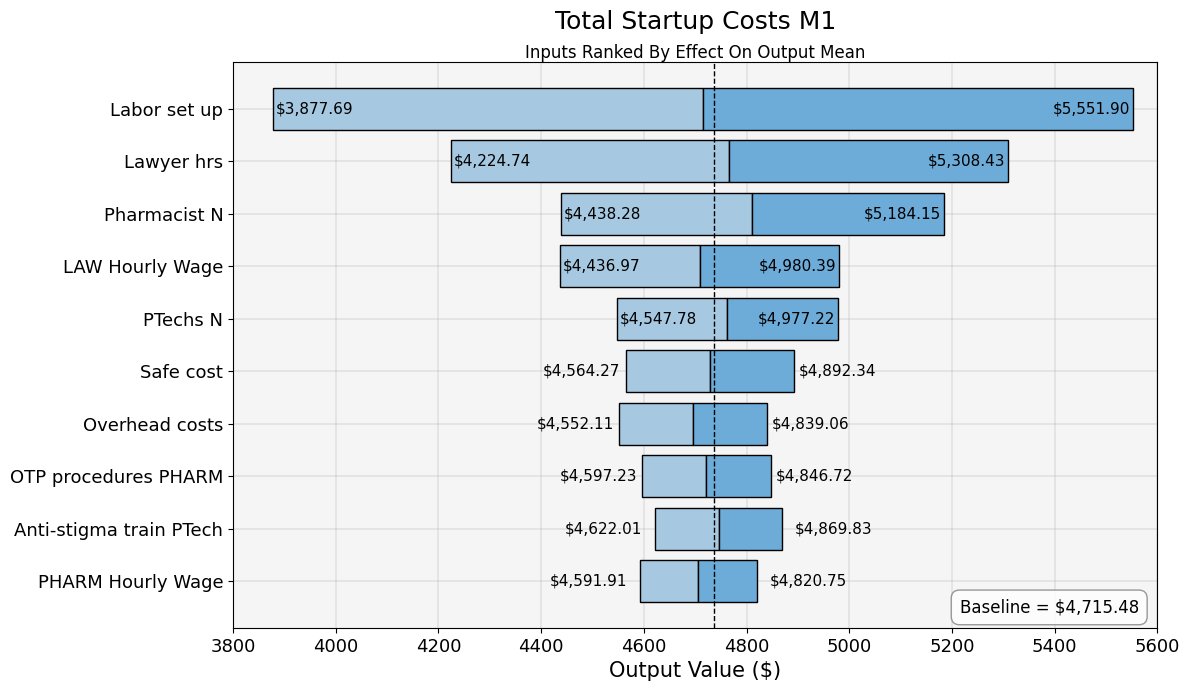

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Reading CSV
df = pd.read_csv(r"C:\Users\murra\Downloads\M1_ROI-Ratio_Tornado_2025-07-18(Sheet1).csv")

# Cleaning data
df.rename(columns={'Unnamed: 0': 'Parameter'}, inplace=True)
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['Y2'] = pd.to_numeric(df['Y2'], errors='coerce')

# Computing midpoint and difference
df['Mid'] = (df['Y'] + df['Y2']) / 2
df['Diff'] = abs(df['Y2'] - df['Y'])

# Sorting by difference for tornado chart
df = df.sort_values('Diff', ascending=True)

# Plotting settings
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.facecolor': '#f5f5f5'
})

fig, ax = plt.subplots(figsize=(12, 7))

problematic_labels = [
    "Safe cost",
    "Overhead costs",
    "OTP procedures PHARM",
    "Anti-stigma train PTech",
    "PHARM Hourly Wage"
]

extra_spacing_labels = [
    "Anti-stigma train PTech",
    "PHARM Hourly Wage"
]

inside_pad = 5
outside_pad = 10
width_threshold = 40

for _, row in df.iterrows():
    y_pos = str(row['Parameter'])
    y1 = row['Y']
    y2 = row['Y2']
    label_L = str(row['L']).strip()
    label_L2 = str(row['L2']).strip()

    start = min(y1, y2)
    end = max(y1, y2)
    mid = (y1 + y2) / 2
    width = end - start

    # Plot left bar (start to mid) - lighter blue
    ax.barh(y_pos, mid - start, left=start, color="#a6c8e0", edgecolor='black')

    # Plot right bar (mid to end) - original blue
    ax.barh(y_pos, end - mid, left=mid, color="#6dabd8", edgecolor='black')

    # Label placement
    if y_pos in problematic_labels:
        offset = 25 if y_pos in extra_spacing_labels else 10
        # Left label outside left bar
        ax.text(start - offset, y_pos, label_L, va='center', ha='right', fontsize=11, color='black')
        # Right label outside right bar
        ax.text(end + offset, y_pos, label_L2, va='center', ha='left', fontsize=11, color='black')
    else:
        if width > width_threshold:
            ax.text(start + inside_pad, y_pos, label_L, va='center', ha='left', fontsize=11, color='black')
            ax.text(end - inside_pad, y_pos, label_L2, va='center', ha='right', fontsize=11, color='black')
        else:
            ax.text(mid - outside_pad, y_pos, label_L, va='center', ha='right', fontsize=11, color='black')
            ax.text(mid + outside_pad, y_pos, label_L2, va='center', ha='left', fontsize=11, color='black')

# Reference line at midpoint average
baseline = df['Mid'].mean()
ax.axvline(x=baseline, color='black', linestyle='--', linewidth=1)

# Axis labels and grid
ax.set_xlim(3800, 5600)
ax.set_xlabel('Output Value ($)')
ax.set_title("")
ax.text(0.5, 1.05, "Total Startup Costs M1", fontsize=18,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(0.5, 1.00, "Inputs Ranked By Effect On Output Mean", fontsize=12,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(
    0.98, 0.02,                           
    f'Baseline = $4,715.48',       
    fontsize=12,
    ha='right', va='bottom',
    transform=ax.transAxes,                
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8)
)
ax.grid(True, linewidth=0.35, alpha=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()